# TASK 1 · Iris Flower Classification

Objective: Train a machine learning classification model to identify the species of an iris flower (Setosa, Versicolor, or Virginica) from its physical measurements.
Tech Stack: Python, scikit-learn, pandas, matplotlib/seaborn, Jupyter Notebook
Feature Checklist:

[ ] Load the Iris dataset (available directly from sklearn.datasets.load_iris() — no download required)

[ ] Perform Exploratory Data Analysis (EDA)**: shape, dtypes, null value check, descriptive statistics

[ ] Visualisations: pairplot or scatter matrix showing feature distributions by species; box plots for each feature

[ ] Feature selection discussion: which features are most discriminative?

[ ] Train/test split (typically 80/20) using train_test_split

[ ] Train at least 2 different classifiers (e.g., Logistic Regression, K-Nearest Neighbours, Decision Tree, Random Forest)

[ ] Evaluate each model: accuracy score, confusion matrix, classification report (precision, recall, F1)

[ ] Identify and declare the best-performing model with justification

[ ] All code in a clean, commented Jupyter Notebook



# Iris Flower Classification Using Machine Learning

### Objective
My aim and objective  of this project is to build machine learning models that can
classify iris flowers into three species:

- Setosa
- Versicolor
- Virginica

i will be using four physical measurements for the  classification and they are 

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

In [4]:
# i have to import all the modules needed to carry out my task on iris flower classification Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import load_iris

# Train-test split
from sklearn.model_selection import train_test_split

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [6]:
#import pandas as pd
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()

# Create a DataFrame from the dataset
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Add the numerical target
df["species"] = iris.target

# Display the first 5 rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [7]:
# Convert numerical target values to species names
df["species_name"] = df["species"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa


In [8]:
# Dataset shape
print("Dataset shape:", df.shape)


Dataset shape: (150, 6)


In [9]:
df.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                int32
species_name          object
dtype: object

In [10]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64

In [11]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [12]:
df["species_name"].value_counts()

species_name
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64

 # Exploratory Data Analysis

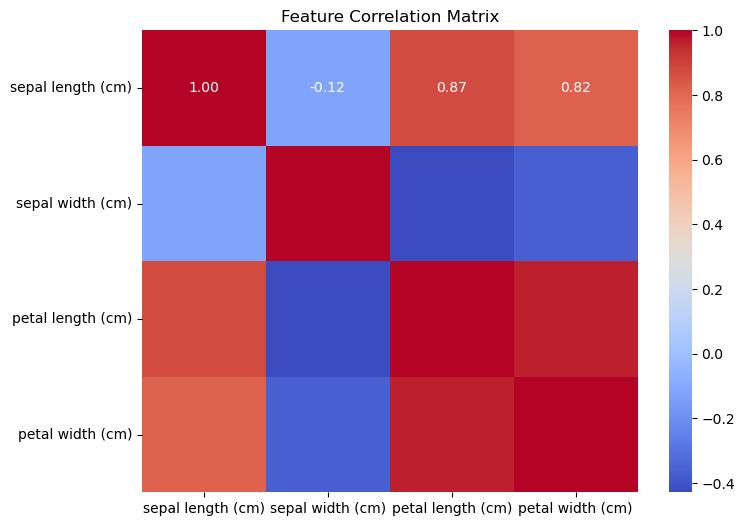

In [16]:
# Correlation matrix
correlation = df[iris.feature_names].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")
plt.show()

C:\Users\DEII\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\DEII\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\DEII\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\DEII\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating ins

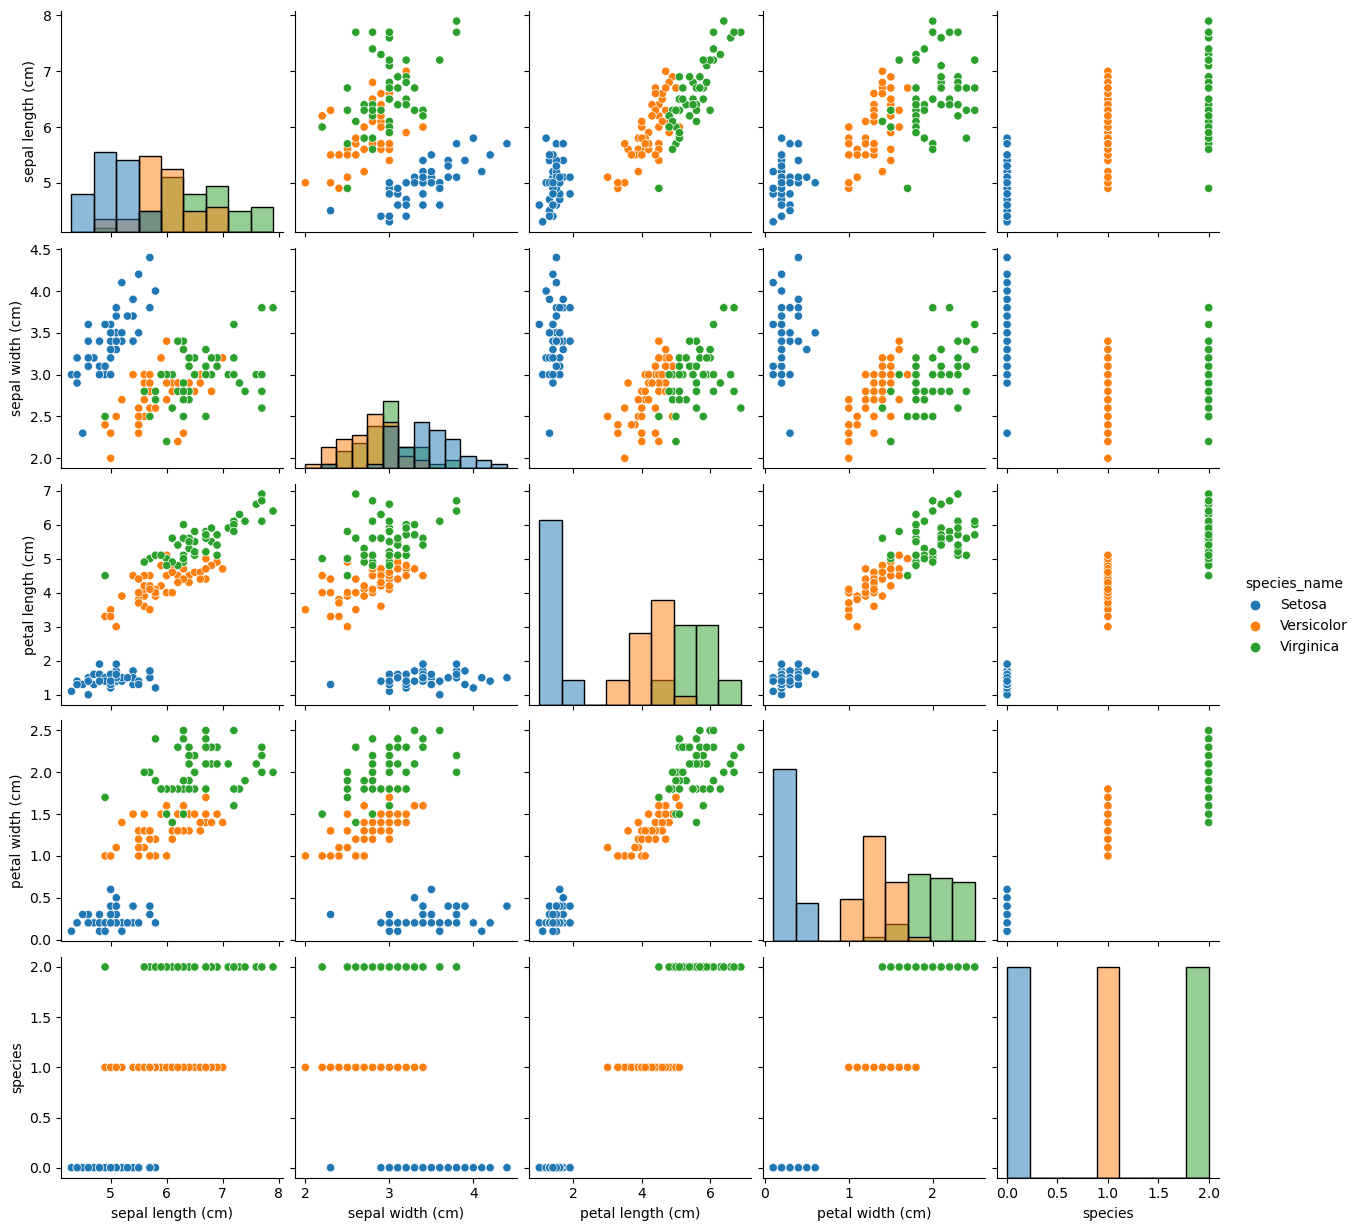

In [14]:
# Select the original four features and species name
sns.pairplot(
    df,
    hue="species_name",
    diag_kind="hist"
)

plt.show()

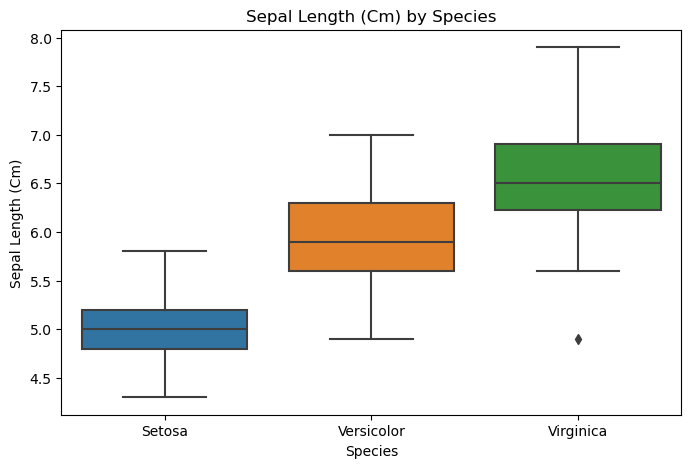

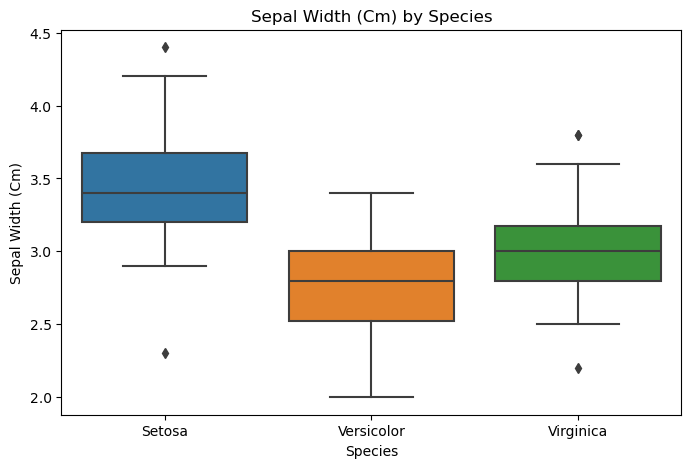

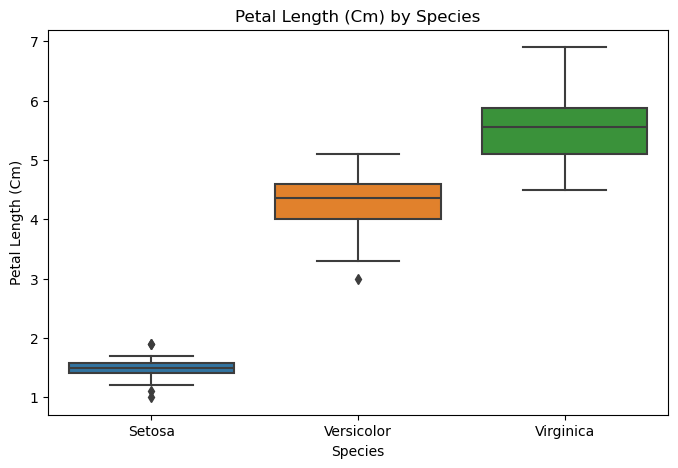

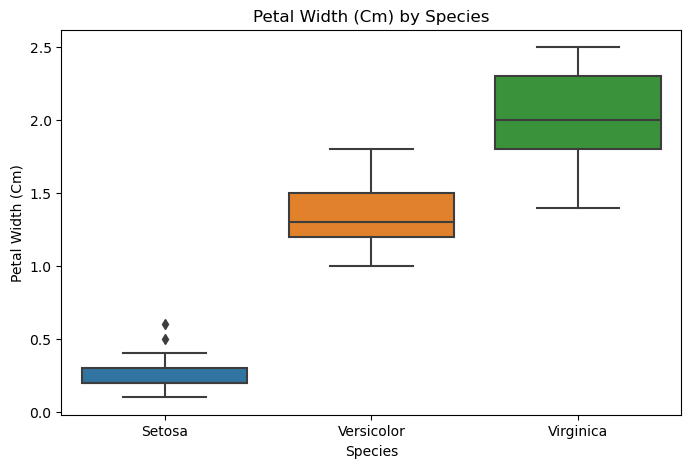

In [17]:
features = iris.feature_names

for feature in features:
    plt.figure(figsize=(8, 5))
    
    sns.boxplot(
        data=df,
        x="species_name",
        y=feature
    )
    
    plt.title(f"{feature.title()} by Species")
    plt.xlabel("Species")
    plt.ylabel(feature.title())
    plt.show()

# Feature Selection Discussion

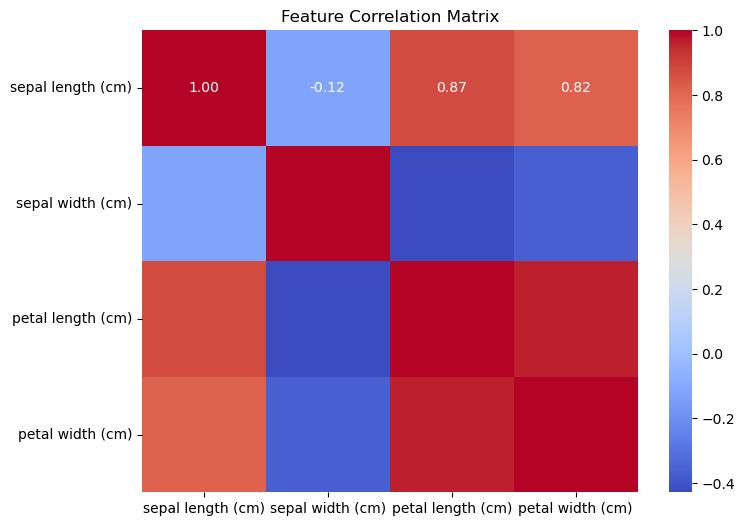

In [18]:
# Correlation matrix
correlation = df[iris.feature_names].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")
plt.show()

## Feature Selection Discussion

The four available features are:

1. Sepal length
2. Sepal width
3. Petal length
4. Petal width

From the pairplot and box plots, petal length and petal width appear to be
the most discriminative features because they provide clearer separation
between the three iris species.

Setosa is particularly easy to distinguish from the other species using
petal measurements.

Versicolor and Virginica have more overlap, although petal length and petal
width still provide useful separation.

For this project, all four features will initially be used to train the
models because they are available and may contribute useful information.

# Prepare Data for Machine Learning

In [19]:
# Features
X = df[iris.feature_names]

# Target
y = df["species"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


# Model 1 — Logistic Regression

In [21]:
# Create Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=200
)

# Train the model
logistic_model.fit(X_train, y_train)

# Make predictions
y_pred_logistic = logistic_model.predict(X_test)

# Accuracy

In [23]:
logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

print("Logistic Regression Accuracy:",
      logistic_accuracy)

Logistic Regression Accuracy: 0.9666666666666667


# Classification Report

In [24]:
print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=iris.target_names
    )
)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



# Logistic Regression Confusion Matrix

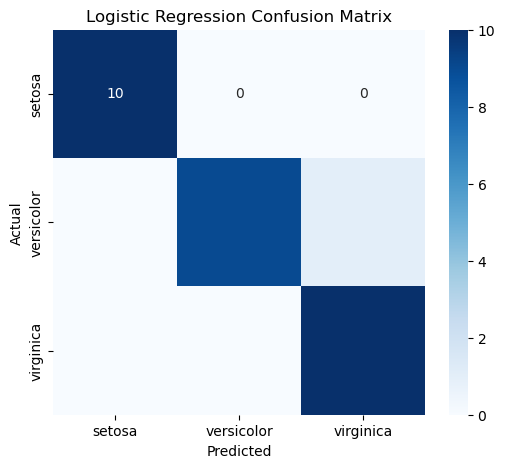

In [25]:
cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

# Model 2 — K-Nearest Neighbours

In [27]:
# Create KNN model
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

# Train the model
knn_model.fit(X_train, y_train)

# Make predictions
y_pred_knn = knn_model.predict(X_test)

# Accuracy 

In [28]:
knn_accuracy = accuracy_score(
    y_test,
    y_pred_knn
)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 1.0


In [29]:
print(
    classification_report(
        y_test,
        y_pred_knn,
        target_names=iris.target_names
    )
)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# KNN Confusion Matrix 

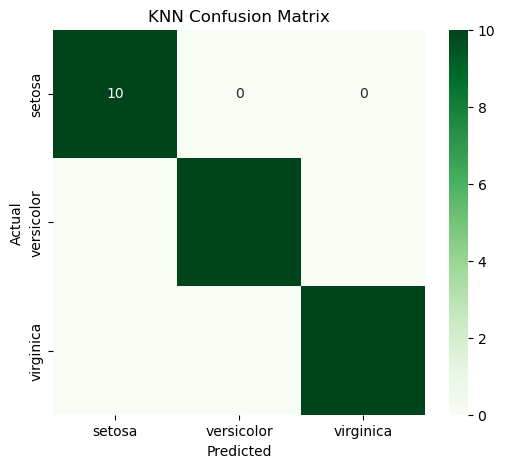

In [30]:
cm_knn = confusion_matrix(
    y_test,
    y_pred_knn
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")

plt.show()

# Comparing the Two Model 

In [31]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "K-Nearest Neighbours"
    ],
    "Accuracy": [
        logistic_accuracy,
        knn_accuracy
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.966667
1,K-Nearest Neighbours,1.000000


# To Automatically decide on the best model

In [32]:
best_model = results.loc[
    results["Accuracy"].idxmax()
]

print("Best Performing Model:")
print(best_model)

Best Performing Model:
Model       K-Nearest Neighbours
Accuracy                     1.0
Name: 1, dtype: object


## Model Comparison and Final Result

Two classification algorithms were trained and evaluated:

- Logistic Regression
- K-Nearest Neighbours

The models were evaluated using accuracy, confusion matrices, precision,
recall, and F1-score.

Based on the experimental results, K-NN    achieved the highest test
accuracy of 1.0.

The K-Nearest Neighbours that has the higher test accuracy was selected as the best-performing
model for this experiment.

 The Confusion Matrix  showed strong precision, recall, and F1-score
across the three classes: Setosa, Versicolor, and Virginica.

The confusion matrix was examined to determine whether any species were
being incorrectly classified.

Overall, the results show that machine learning can effectively classify
iris flowers using their physical measurements.